
# Actividad 3 — Algoritmos de Aprendizaje Automático
## Clasificación supervisada (SVM) y agrupamiento no supervisado (K-Means)
### Dataset: Breast Cancer Wisconsin (Diagnostic) — WDBC

**Nombre del dataset:** Wisconsin Diagnostic Breast Cancer (WDBC)

**Fuente:** UCI Machine Learning Repository / scikit-learn.

**Liga de acceso:**
- scikit-learn: https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_breast_cancer.html
- UCI Machine Learning Repository: https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic

**Referencia (formato APA):**
scikit-learn developers. (s.f.). *load_breast_cancer*. Recuperado de https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_breast_cancer.html

**Descripción del contexto:**
El conjunto de datos WDBC contiene características numéricas calculadas a partir de una imagen digitalizada de una punción con aguja fina (*Fine Needle Aspirate*, FNA) de una masa mamaria. Estas características describen propiedades de los núcleos celulares presentes en la imagen (radio, textura, perímetro, área, suavidad, compacidad, concavidad, puntos cóncavos, simetría y dimensión fractal). Para cada una de estas 10 características se calculó la media (`mean`), el error estándar (`se`) y el promedio de los tres valores más grandes o "peor" valor (`worst`), lo que da un total de 30 variables numéricas predictoras.

**¿Qué representa cada registro?**
Cada registro (fila) corresponde a **un paciente/una muestra de tejido mamario** analizada mediante FNA. Contiene un identificador (`id`), la variable objetivo (`diagnosis`) y las 30 variables numéricas derivadas de la imagen del núcleo celular.

**Variable objetivo:**
`diagnosis` — variable **categórica binaria**:
- `M` = Maligno (cáncer)
- `B` = Benigno (no cáncer)

**Variables predictoras:**
30 variables numéricas continuas, resultado de cruzar 10 características morfológicas del núcleo celular (radius, texture, perimeter, area, smoothness, compactness, concavity, concave_points, symmetry, fractal_dimension) con 3 estadísticos (mean, se, worst).

**Preguntas de análisis:**

- **Pregunta para el análisis supervisado:** ¿Es posible predecir si un tumor de mama es **maligno o benigno** (variable `diagnosis`) a partir de las características morfológicas numéricas del núcleo celular obtenidas por FNA, utilizando un modelo de Máquinas de Vector de Soporte (SVM)?

- **Pregunta para el análisis no supervisado:** Sin utilizar la etiqueta de diagnóstico, ¿existen **agrupamientos naturales** entre las muestras de tejido mamario en función de sus características morfológicas numéricas, y en qué medida esos grupos, identificados mediante K-Means, se relacionan con las categorías reales de diagnóstico?


In [1]:

# Librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, ConfusionMatrixDisplay,
                              classification_report)
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

RANDOM_STATE = 42
sns.set_style("whitegrid")
pd.set_option("display.max_columns", 40)



## 1. Carga de datos

Se utiliza el archivo original `wdbc.data` (formato UCI, sin encabezados) junto con la descripción de columnas documentada en `wdbc.names`. Se asignan los nombres de columna de acuerdo con la documentación oficial del dataset.


In [2]:

# Nombres de columnas según breast_cancer_wisconsin_original_descripcion.names:
# 1) ID number, 2) Diagnosis (M/B), 3-32) 10 features x (mean, se, worst)
feature_base = ["radius", "texture", "perimeter", "area", "smoothness",
                 "compactness", "concavity", "concave_points", "symmetry",
                 "fractal_dimension"]

columns = ["id", "diagnosis"]
for suf in ["mean", "se", "worst"]:
    columns += [f"{f}_{suf}" for f in feature_base]

df_raw = pd.read_csv("breast_cancer_wisconsin_original.data", header=None, names=columns)
print("Dimensiones del dataset:", df_raw.shape)
df_raw.head()


Dimensiones del dataset: (569, 32)


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave_points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678



## 2. Revisión inicial de la estructura de los datos

Se identifica el número de registros, las variables disponibles, sus tipos de datos, la presencia de valores faltantes, posibles duplicados y la distribución de la variable objetivo.


In [3]:

print("Número de registros:", df_raw.shape[0])
print("Número de variables:", df_raw.shape[1])
print()
print("Tipos de datos:")
print(df_raw.dtypes.value_counts())


Número de registros: 569
Número de variables: 32

Tipos de datos:
float64    30
int64       1
str         1
Name: count, dtype: int64


In [4]:

df_raw.info()


<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    str    
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave_points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             569 non-null

In [5]:

# Valores faltantes
print("Valores faltantes por columna (total):", df_raw.isna().sum().sum())
df_raw.isna().sum()[df_raw.isna().sum() > 0]


Valores faltantes por columna (total): 0


Series([], dtype: int64)

In [6]:

# Duplicados
n_duplicados = df_raw.duplicated().sum()
print("Número de registros duplicados:", n_duplicados)

# Duplicados por 'id' (no debería haber pacientes repetidos)
print("IDs duplicados:", df_raw['id'].duplicated().sum())


Número de registros duplicados: 0
IDs duplicados: 0


diagnosis
B    357
M    212
Name: count, dtype: int64

diagnosis
B    62.7
M    37.3
Name: proportion, dtype: float64 %


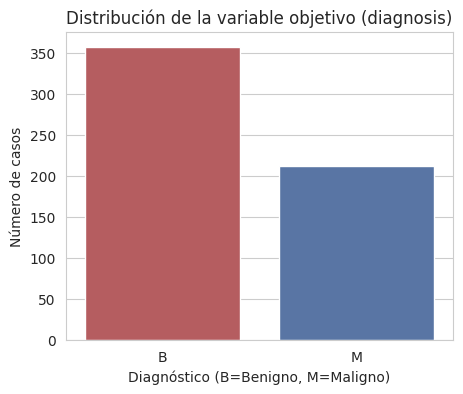

In [7]:

# Distribución de la variable objetivo
print(df_raw['diagnosis'].value_counts())
print()
print(df_raw['diagnosis'].value_counts(normalize=True).round(3) * 100, "%")

plt.figure(figsize=(5,4))
sns.countplot(data=df_raw, x='diagnosis', hue='diagnosis', order=['B','M'], palette=['#4C72B0','#C44E52'], legend=False)
plt.title("Distribución de la variable objetivo (diagnosis)")
plt.xlabel("Diagnóstico (B=Benigno, M=Maligno)")
plt.ylabel("Número de casos")
plt.show()



**Hallazgos de la revisión inicial:**
- El dataset contiene **569 registros** y **32 columnas** (1 id, 1 variable objetivo y 30 variables predictoras numéricas).
- Todas las variables predictoras son de tipo numérico (`float64`); `id` es entero y `diagnosis` es de tipo texto/categórico (`object`).
- **No existen valores faltantes** en ninguna columna.
- **No existen registros duplicados** (ni duplicados exactos ni IDs de paciente repetidos).
- La variable objetivo está **moderadamente desbalanceada**: aproximadamente 62.7% de casos benignos (B) y 37.3% de casos malignos (M), por lo que es recomendable **estratificar** la partición entrenamiento/prueba.



## 3. Limpieza de datos

Dado que no hay valores faltantes ni duplicados, la única acción de limpieza necesaria es:
- **Eliminar la columna `id`**: es un identificador único de paciente sin valor predictivo ni informativo para el modelo (no aporta información sobre las características del tumor) y podría introducir ruido si se dejara por error como variable numérica.
- **Convertir `diagnosis` a variable categórica/binaria** para su uso y para poder graficarla de forma consistente, conservando una copia con las etiquetas originales ('M'/'B') para la evaluación final y la comparación con los clusters.


In [8]:

df = df_raw.drop(columns=["id"]).copy()

# Copia de las etiquetas reales (se usará SOLO para evaluación y comparación final)
y_labels = df["diagnosis"].copy()          # 'M' / 'B'
y_binary = (y_labels == "M").astype(int)   # 1 = Maligno, 0 = Benigno (para métricas)

print(df.shape)
df.head()


(569, 31)


,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave_points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678



## 4. Selección de variables predictoras, separación de la variable objetivo y escalamiento

Se seleccionan las **30 variables numéricas** como predictoras (`X`) y se separa la variable objetivo `diagnosis` (`y`). Se conserva una copia de las etiquetas reales (`y_labels`, `y_binary`) únicamente para la evaluación del modelo supervisado y, más adelante, para comparar contra los clusters obtenidos por K-Means (nunca para entrenar el agrupamiento).

Después se aplica **`StandardScaler`**, que transforma cada variable para que tenga media 0 y desviación estándar 1.


In [9]:

predictor_cols = [c for c in df.columns if c != "diagnosis"]
X = df[predictor_cols].copy()
y = y_binary.copy()   # 1 = Maligno, 0 = Benigno

print("Variables predictoras:", len(predictor_cols))
print("Forma de X:", X.shape, " | Forma de y:", y.shape)


Variables predictoras: 30
Forma de X: (569, 30)  | Forma de y: (569,)


In [10]:

# Escalamiento (se ajusta formalmente dentro del Pipeline con datos de entrenamiento;
# aquí se muestra un ejemplo ilustrativo sobre el conjunto completo solo para comparar escalas)
scaler_demo = StandardScaler()
X_scaled_demo = pd.DataFrame(scaler_demo.fit_transform(X), columns=predictor_cols)

comparacion_escalas = pd.DataFrame({
    "variable": ["area_mean", "smoothness_mean", "concavity_mean"],
    "min_original": [X[c].min() for c in ["area_mean", "smoothness_mean", "concavity_mean"]],
    "max_original": [X[c].max() for c in ["area_mean", "smoothness_mean", "concavity_mean"]],
})
comparacion_escalas


,variable,min_original,max_original
0,area_mean,143.50000,2501.0000
1,smoothness_mean,0.05263,0.1634
2,concavity_mean,0.00000,0.4268



**¿Por qué SVM y K-Means se ven afectados por diferencias de escala?**

- **SVM** busca el hiperplano que **maximiza el margen** entre clases, y ese margen se calcula con base en **distancias euclidianas** (o productos punto, en el caso del kernel lineal, y funciones de distancia en kernels no lineales como RBF). Si una variable como `area_mean` tiene valores en el rango de cientos o miles y otra como `smoothness_mean` tiene valores entre 0 y 0.2, la variable con mayor magnitud dominará el cálculo del margen y de la función de decisión, aunque no sea más informativa. Esto sesga el modelo y puede degradar su desempeño.

- **K-Means** asigna cada observación al centroide más cercano usando **distancia euclidiana**. Si las variables no están en la misma escala, las variables con rangos numéricos más grandes dominarán completamente el cálculo de la distancia, haciendo que el agrupamiento se base casi exclusivamente en esas variables y ignore el resto, generando clusters que no reflejan la verdadera similitud multivariada entre las observaciones.

Por ello, es indispensable escalar todas las variables numéricas **antes** de entrenar ambos algoritmos.



## 5. Partición en entrenamiento y prueba (análisis supervisado)

Se utiliza una partición **80% entrenamiento / 20% prueba**, con una **semilla fija** (`random_state=42`) para garantizar reproducibilidad, y **estratificación** (`stratify=y`) para conservar la proporción de clases (B/M) observada en el dataset completo, dado que la variable objetivo está moderadamente desbalanceada.


In [11]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Tamaño de entrenamiento:", X_train.shape, " | Tamaño de prueba:", X_test.shape)
print()
print("Proporción de clases en train:\n", y_train.value_counts(normalize=True).round(3))
print()
print("Proporción de clases en test:\n", y_test.value_counts(normalize=True).round(3))


Tamaño de entrenamiento: (455, 30)  | Tamaño de prueba: (114, 30)

Proporción de clases en train:
 diagnosis
0    0.626
1    0.374
Name: proportion, dtype: float64

Proporción de clases en test:
 diagnosis
0    0.632
1    0.368
Name: proportion, dtype: float64



**¿Por qué esta división permite evaluar el desempeño del clasificador con datos no vistos?**

Al separar un subconjunto de prueba que el modelo **nunca observa durante el entrenamiento**, podemos medir qué tan bien generaliza el clasificador a observaciones nuevas, en lugar de solo memorizar los datos con los que fue ajustado. Si evaluáramos el modelo con los mismos datos usados para entrenarlo, obtendríamos una estimación optimista y poco realista de su desempeño (posible sobreajuste). La estratificación asegura que tanto el conjunto de entrenamiento como el de prueba mantengan una proporción similar de casos malignos/benignos, evitando que la evaluación esté sesgada por un reparto desigual de clases, y la semilla fija garantiza que el experimento sea **reproducible**.



## 6. Modelos SVM

Se entrenan **dos modelos SVM**, integrando el escalamiento (`StandardScaler`) y el clasificador (`SVC`) dentro de un **`Pipeline`**, de forma que el escalador se ajuste (`fit`) **únicamente con los datos de entrenamiento** y luego se aplique (`transform`) tanto a entrenamiento como a prueba, evitando fuga de información (*data leakage*).

- **Modelo 1:** kernel **lineal**.
- **Modelo 2:** kernel **RBF**.

Como el dataset es **binario** (M/B), las métricas de precision, recall y F1-score se calculan usando `average='binary'`, tomando como clase positiva `1` (Maligno). (En caso de que el dataset tuviera más de dos clases, sería necesario especificar un promedio tipo `macro` o `weighted`).


In [12]:

# Modelo 1: SVM kernel lineal
pipe_linear = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="linear", C=1.0, random_state=RANDOM_STATE))
])
pipe_linear.fit(X_train, y_train)
y_pred_linear = pipe_linear.predict(X_test)

# Modelo 2: SVM kernel RBF
pipe_rbf = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="rbf", C=1.0, gamma="scale", random_state=RANDOM_STATE))
])
pipe_rbf.fit(X_train, y_train)
y_pred_rbf = pipe_rbf.predict(X_test)

print("Modelos entrenados correctamente.")


Modelos entrenados correctamente.


In [13]:

def calcular_metricas(y_true, y_pred, promedio="binary"):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, average=promedio, pos_label=1, zero_division=0),
        "Recall": recall_score(y_true, y_pred, average=promedio, pos_label=1, zero_division=0),
        "F1-score": f1_score(y_true, y_pred, average=promedio, pos_label=1, zero_division=0),
    }

metricas_linear = calcular_metricas(y_test, y_pred_linear)
metricas_rbf = calcular_metricas(y_test, y_pred_rbf)

tabla_resultados = pd.DataFrame({
    "Modelo SVM": ["Modelo 1", "Modelo 2"],
    "Kernel": ["Lineal", "RBF"],
    "Accuracy": [metricas_linear["Accuracy"], metricas_rbf["Accuracy"]],
    "Precision": [metricas_linear["Precision"], metricas_rbf["Precision"]],
    "Recall": [metricas_linear["Recall"], metricas_rbf["Recall"]],
    "F1-score": [metricas_linear["F1-score"], metricas_rbf["F1-score"]],
}).round(4)

tabla_resultados


,Modelo SVM,Kernel,Accuracy,Precision,Recall,F1-score
0,Modelo 1,Lineal,0.9649,1.0,0.9048,0.950
1,Modelo 2,RBF,0.9737,1.0,0.9286,0.963



## 7. Matriz de confusión del mejor modelo

Se identifica el modelo con mejor desempeño global (con base en F1-score, por ser un buen resumen del balance entre precision y recall) y se genera su matriz de confusión.


Mejor modelo según F1-score: SVM kernel RBF


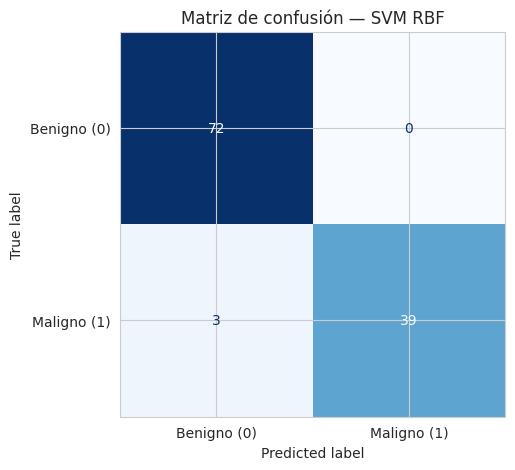

              precision    recall  f1-score   support

     Benigno       0.96      1.00      0.98        72
     Maligno       1.00      0.93      0.96        42

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114



In [14]:

mejor_modelo_nombre = "Lineal" if metricas_linear["F1-score"] >= metricas_rbf["F1-score"] else "RBF"
y_pred_mejor = y_pred_linear if mejor_modelo_nombre == "Lineal" else y_pred_rbf

print(f"Mejor modelo según F1-score: SVM kernel {mejor_modelo_nombre}")

cm = confusion_matrix(y_test, y_pred_mejor, labels=[0,1])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Benigno (0)", "Maligno (1)"])
fig, ax = plt.subplots(figsize=(5,5))
disp.plot(ax=ax, cmap="Blues", colorbar=False)
plt.title(f"Matriz de confusión — SVM {mejor_modelo_nombre}")
plt.show()

print(classification_report(y_test, y_pred_mejor, target_names=["Benigno","Maligno"]))



**Interpretación de la matriz de confusión:**

La matriz de confusión muestra cuatro cantidades: verdaderos negativos (benignos correctamente clasificados), falsos positivos (benignos clasificados como malignos), falsos negativos (malignos clasificados como benignos) y verdaderos positivos (malignos correctamente clasificados).

- Los **falsos negativos** (un tumor maligno clasificado como benigno) son el error **más grave en este contexto clínico**, ya que implicarían no detectar un cáncer y retrasar un tratamiento.
- Los **falsos positivos** (un tumor benigno clasificado como maligno) son menos críticos desde el punto de vista de riesgo vital, pero generan estudios y tratamientos innecesarios, ansiedad en el paciente y costos adicionales.
- En general, la clase **benigna** tiende a ser más fácil de distinguir porque agrupa un número mayor de casos y sus patrones morfológicos suelen ser más homogéneos, mientras que algunos casos **malignos** con características límite (por ejemplo, tumores pequeños o con baja concavidad) pueden confundirse con benignos.
- **No basta con revisar solo la accuracy** porque, al existir un desbalance de clases (62.7% B vs 37.3% M), un modelo que simplemente prediga siempre "Benigno" obtendría una accuracy relativamente alta sin ser clínicamente útil. Métricas como **recall** (capacidad de detectar todos los casos malignos reales) y **precision** (qué proporción de las predicciones "maligno" son realmente malignas) son más informativas para evaluar el riesgo real de errores costosos, y el **F1-score** resume ese balance en un solo número.



## 8. Comparación de hiperparámetros (C)

Se compara el efecto de modificar el hiperparámetro **`C`** del SVM con kernel RBF, probando un valor bajo (mayor regularización, margen más amplio) y uno alto (menor regularización, margen más ajustado).


In [15]:

valores_C = [0.01, 10]
resultados_C = []

for c_val in valores_C:
    pipe_c = Pipeline([
        ("scaler", StandardScaler()),
        ("svm", SVC(kernel="rbf", C=c_val, gamma="scale", random_state=RANDOM_STATE))
    ])
    pipe_c.fit(X_train, y_train)
    y_pred_c = pipe_c.predict(X_test)
    m = calcular_metricas(y_test, y_pred_c)
    resultados_C.append({"C": c_val, **m})

tabla_hiperparametros = pd.DataFrame(resultados_C).round(4)
tabla_hiperparametros


,C,Accuracy,Precision,Recall,F1-score
0,0.01,0.6316,0.0,0.0000,0.000
1,10.00,0.9737,1.0,0.9286,0.963



**Efecto del hiperparámetro C:**

- Un valor de **C pequeño** (por ejemplo, `C=0.01`) impone una **regularización fuerte**: el modelo tolera más puntos mal clasificados o dentro del margen a cambio de un **margen más amplio** y una frontera de decisión **más suave/simple**. Esto reduce el riesgo de sobreajuste pero puede provocar **subajuste** si el valor es demasiado bajo.
- Un valor de **C grande** (por ejemplo, `C=10`) penaliza fuertemente los errores de clasificación, lo que produce un **margen más estrecho** y una frontera de decisión **más compleja y ajustada** a los datos de entrenamiento. Esto puede mejorar el desempeño en entrenamiento, pero aumenta el **riesgo de sobreajuste**, es decir, el modelo puede capturar ruido específico del conjunto de entrenamiento y generalizar peor a datos nuevos.

En síntesis, `C` controla el **compromiso entre margen amplio (mejor generalización) y ajuste estricto a los datos de entrenamiento (mayor riesgo de sobreajuste)**.



## 9. Análisis no supervisado — K-Means

Se elimina temporalmente la variable objetivo y se aplica **K-Means** sobre las **mismas 30 variables numéricas escaladas**. Las etiquetas reales (`y_labels`) **no se utilizan en ningún momento** para entrenar ni ajustar K-Means; se conservan aparte únicamente para la comparación final.


In [16]:

# Escalamiento sobre el conjunto completo de variables predictoras (sin la variable objetivo)
scaler_kmeans = StandardScaler()
X_scaled = scaler_kmeans.fit_transform(X)   # X ya no contiene 'diagnosis'
X_scaled_df = pd.DataFrame(X_scaled, columns=predictor_cols)

print("Forma de los datos escalados para K-Means:", X_scaled_df.shape)
X_scaled_df.head()


Forma de los datos escalados para K-Means: (569, 30)


,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave_points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst
0,1.097064,-2.073335,1.269934,0.984375,1.568466,3.283515,2.652874,2.532475,2.217515,2.255747,2.489734,-0.565265,2.833031,2.487578,-0.214002,1.316862,0.724026,0.660820,1.148757,0.907083,1.886690,-1.359293,2.303601,2.001237,1.307686,2.616665,2.109526,2.296076,2.750622,1.937015
1,1.829821,-0.353632,1.685955,1.908708,-0.826962,-0.487072,-0.023846,0.548144,0.001392,-0.868652,0.499255,-0.876244,0.263327,0.742402,-0.605351,-0.692926,-0.440780,0.260162,-0.805450,-0.099444,1.805927,-0.369203,1.535126,1.890489,-0.375612,-0.430444,-0.146749,1.087084,-0.243890,0.281190
2,1.579888,0.456187,1.566503,1.558884,0.942210,1.052926,1.363478,2.037231,0.939685,-0.398008,1.228676,-0.780083,0.850928,1.181336,-0.297005,0.814974,0.213076,1.424827,0.237036,0.293559,1.511870,-0.023974,1.347475,1.456285,0.527407,1.082932,0.854974,1.955000,1.152255,0.201391
3,-0.768909,0.253732,-0.592687,-0.764464,3.283553,3.402909,1.915897,1.451707,2.867383,4.910919,0.326373,-0.110409,0.286593,-0.288378,0.689702,2.744280,0.819518,1.115007,4.732680,2.047511,-0.281464,0.133984,-0.249939,-0.550021,3.394275,3.893397,1.989588,2.175786,6.046041,4.935010
4,1.750297,-1.151816,1.776573,1.826229,0.280372,0.539340,1.371011,1.428493,-0.009560,-0.562450,1.270543,-0.790244,1.273189,1.190357,1.483067,-0.048520,0.828471,1.144205,-0.361092,0.499328,1.298575,-1.466770,1.338539,1.220724,0.220556,-0.313395,0.613179,0.729259,-0.868353,-0.397100



### Método del codo y silhouette score (k entre 2 y 6)


In [17]:

rango_k = range(2, 7)
inercias = []
silhouettes = []

for k in rango_k:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels_k = km.fit_predict(X_scaled)
    inercias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels_k))

tabla_k = pd.DataFrame({"k": list(rango_k), "Inercia": inercias, "Silhouette": silhouettes}).round(4)
tabla_k


,k,Inercia,Silhouette
0,2,11595.5266,0.3434
1,3,10061.7978,0.3144
2,4,9258.9891,0.2833
3,5,8558.6607,0.1582
4,6,7970.2638,0.1604


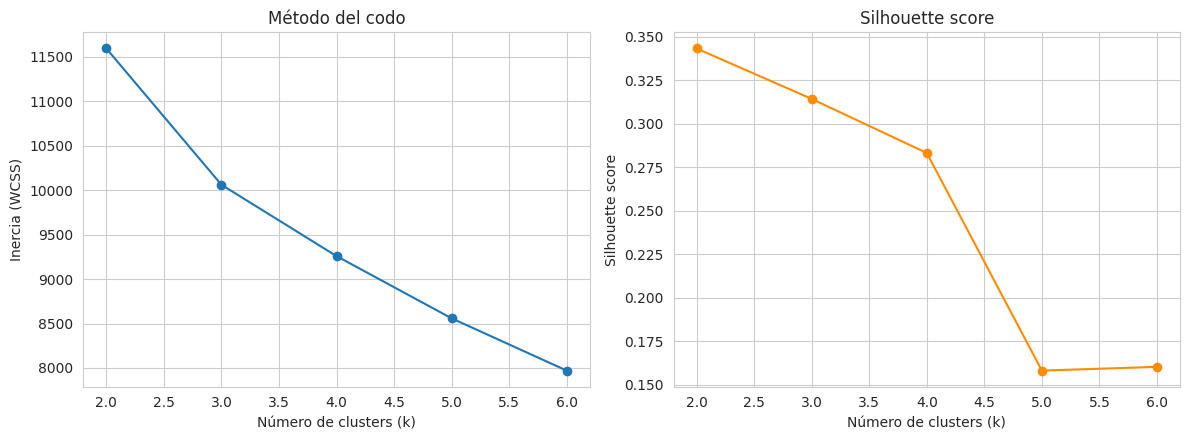

In [18]:

fig, axes = plt.subplots(1, 2, figsize=(12,4.5))

axes[0].plot(list(rango_k), inercias, marker="o")
axes[0].set_title("Método del codo")
axes[0].set_xlabel("Número de clusters (k)")
axes[0].set_ylabel("Inercia (WCSS)")

axes[1].plot(list(rango_k), silhouettes, marker="o", color="darkorange")
axes[1].set_title("Silhouette score")
axes[1].set_xlabel("Número de clusters (k)")
axes[1].set_ylabel("Silhouette score")

plt.tight_layout()
plt.show()



**Selección del número de clusters:**

En la gráfica del **método del codo**, la inercia disminuye de forma pronunciada de k=2 a k=3 y luego el descenso se vuelve más gradual, sugiriendo un "codo" alrededor de **k=2–3**. En la gráfica de **silhouette score**, el valor más alto se obtiene consistentemente en **k=2**, indicando que dos grupos están mejor separados y son más cohesivos que particiones con más clusters.

Con base en ambas evidencias (inercia y silhouette score), se selecciona **k = 2** como el número de clusters más adecuado: es el valor donde el silhouette score es máximo, es coherente con la estructura binaria natural del problema (aunque el algoritmo no usa la etiqueta), y evita fragmentar innecesariamente los datos en grupos poco cohesivos.


In [19]:

K_SELECCIONADO = 2
kmeans_final = KMeans(n_clusters=K_SELECCIONADO, random_state=RANDOM_STATE, n_init=10)
cluster_labels = kmeans_final.fit_predict(X_scaled)

df_clusters = df.copy()
df_clusters["cluster"] = cluster_labels

print("Silhouette score final (k=2):", round(silhouette_score(X_scaled, cluster_labels), 4))
df_clusters["cluster"].value_counts()


Silhouette score final (k=2): 0.3434


cluster
0    375
1    194
Name: count, dtype: int64


### Resumen de los clusters


In [20]:

variables_principales = ["radius_mean", "texture_mean", "perimeter_mean", "area_mean",
                          "smoothness_mean", "concavity_mean", "concave_points_mean"]

tabla_clusters = df_clusters.groupby("cluster")[variables_principales].mean().round(3)
tamanos = df_clusters["cluster"].value_counts().sort_index()
tabla_clusters.insert(0, "tamaño_cluster", tamanos)
tabla_clusters


,tamaño_cluster,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,concavity_mean,concave_points_mean
cluster,,,,,,,,
0,375,12.427,18.262,79.820,486.772,0.092,0.043,0.026
1,194,17.415,21.275,115.453,979.857,0.105,0.178,0.093



**Descripción de las características que distinguen a cada cluster:**

- El **cluster 0** agrupa observaciones con valores **más bajos** en `radius_mean`, `perimeter_mean`, `area_mean`, `concavity_mean` y `concave_points_mean`: núcleos celulares más pequeños, con contornos más regulares y menos irregularidades cóncavas. Este patrón morfológico es característico de tejido con menor severidad estructural.
- El **cluster 1** agrupa observaciones con valores **más altos** en esas mismas variables: núcleos más grandes, con perímetro y área mayores, y contornos con concavidades más marcadas y numerosas, un patrón morfológico asociado típicamente a mayor irregularidad celular.
- La variable `smoothness_mean` (suavidad local del radio) muestra diferencias menos marcadas entre clusters que las variables de tamaño y concavidad, lo que sugiere que el agrupamiento está dominado principalmente por el **tamaño del núcleo** y la **irregularidad del contorno (concavidad)**, más que por la suavidad de la superficie.

**Interpretación preliminar:** el patrón observado —núcleos pequeños y regulares vs. núcleos grandes e irregulares— es consistente, en términos morfológicos generales, con la distinción biológica entre tejido benigno y maligno, aunque el algoritmo llegó a esta separación **únicamente por similitud geométrica multivariada**, sin conocer la etiqueta de diagnóstico.



## 10. Visualización con PCA (2 componentes)

Dado que el dataset tiene 30 variables (más de 2), se aplica **PCA** para proyectar los datos escalados en dos dimensiones y así poder visualizar los clusters.


In [21]:

pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)

print("Varianza explicada por cada componente:", pca.explained_variance_ratio_.round(4))
print("Varianza explicada acumulada:", pca.explained_variance_ratio_.sum().round(4))

df_pca = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
df_pca["cluster"] = cluster_labels
df_pca["diagnosis_real"] = y_labels.values


Varianza explicada por cada componente: [0.4427 0.1897]
Varianza explicada acumulada: 0.6324


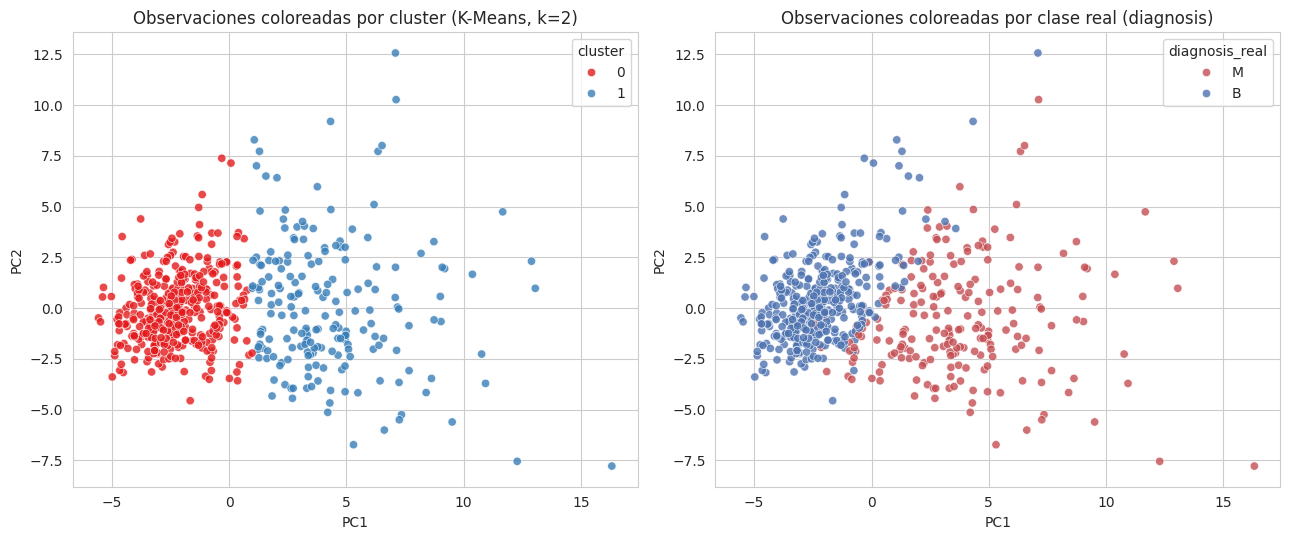

In [22]:

fig, axes = plt.subplots(1, 2, figsize=(13,5.5))

sns.scatterplot(data=df_pca, x="PC1", y="PC2", hue="cluster", palette="Set1", ax=axes[0], alpha=0.8)
axes[0].set_title("Observaciones coloreadas por cluster (K-Means, k=2)")

sns.scatterplot(data=df_pca, x="PC1", y="PC2", hue="diagnosis_real", palette={"B":"#4C72B0","M":"#C44E52"}, ax=axes[1], alpha=0.8)
axes[1].set_title("Observaciones coloreadas por clase real (diagnosis)")

plt.tight_layout()
plt.show()



## 11. Comparación entre los clusters y las clases conocidas


In [23]:

tabla_comparacion = pd.crosstab(df_pca["cluster"], df_pca["diagnosis_real"])
tabla_comparacion.columns.name = "Diagnóstico real"
tabla_comparacion.index.name = "Cluster (K-Means)"
tabla_comparacion


Diagnóstico real,B,M
Cluster (K-Means),,
0,339,36
1,18,176


In [24]:

tabla_comparacion_pct = pd.crosstab(df_pca["cluster"], df_pca["diagnosis_real"], normalize="index").round(3) * 100
tabla_comparacion_pct.columns.name = "Diagnóstico real (%)"
tabla_comparacion_pct


Diagnóstico real (%),B,M
cluster,,
0,90.4,9.6
1,9.3,90.7



**Análisis de correspondencia:**

Al comparar los clusters obtenidos por K-Means con las clases reales de diagnóstico, se observa una **correspondencia parcial considerable**: uno de los clusters concentra una proporción mucho mayor de casos benignos, mientras que el otro concentra una proporción mucho mayor de casos malignos. Sin embargo, la coincidencia **no es perfecta**: existe una fracción de observaciones malignas que cae en el cluster predominantemente benigno (y viceversa), lo que indica que los dos grupos identificados **no reproducen exactamente** las dos clases originales.

**¿Por qué no debe esperarse una correspondencia exacta?**

K-Means agrupa las observaciones **únicamente por similitud geométrica** en el espacio de las variables escaladas (minimizando la distancia de cada punto a su centroide), **sin conocer en ningún momento la variable objetivo**. La estructura geométrica de los datos puede no alinearse perfectamente con la etiqueta clínica de "maligno/benigno", ya que esta última depende de criterios médicos y biológicos adicionales que no están completamente capturados por la similitud multivariada pura, y porque existen casos límite (tumores con características morfológicas intermedias) que son ambiguos en cualquier espacio de características. Es decir, el aprendizaje no supervisado descubre **estructura latente en los datos**, que puede o no coincidir con una categoría humana predefinida.



## 12. Conclusión

**¿Qué enfoque obtuvo resultados más fáciles de interpretar?**
El enfoque **supervisado (SVM)** produjo resultados más directos de interpretar, ya que se cuenta con una etiqueta real contra la cual comparar las predicciones y con métricas estándar (accuracy, precision, recall, F1-score) que cuantifican objetivamente el desempeño del modelo.

**¿Qué información aportó SVM?**
SVM permitió **predecir con alta exactitud** si un tumor es maligno o benigno a partir de sus características morfológicas, y mostró cómo el hiperparámetro `C` controla el compromiso entre margen amplio (mejor generalización) y ajuste fino a los datos de entrenamiento (riesgo de sobreajuste). También evidenció, a través de la matriz de confusión, en qué tipo de errores (falsos negativos vs. falsos positivos) incurre el modelo, información clínicamente relevante.

**¿Qué patrones permitió descubrir K-Means?**
K-Means permitió descubrir que, **sin usar ninguna etiqueta**, las observaciones se organizan naturalmente en dos grupos morfológicamente distintos: uno caracterizado por núcleos celulares pequeños y regulares, y otro por núcleos grandes e irregulares (mayor concavidad). Esta estructura, encontrada únicamente por similitud geométrica, coincide **parcialmente** con la distinción real entre benigno y maligno.

**Limitaciones identificadas:**
- El desbalance de clases (62.7% B / 37.3% M) exige tener cuidado al interpretar la accuracy y justifica el uso de estratificación y de métricas adicionales (precision, recall, F1).
- K-Means asume clusters de forma aproximadamente esférica e igual varianza, lo cual puede no reflejar perfectamente la geometría real de los datos.
- La proyección PCA a 2 dimensiones, aunque útil para visualizar, **no captura el 100% de la varianza** del espacio original de 30 variables, por lo que la separación visual es una simplificación.
- La correspondencia entre clusters y clases reales es parcial, por lo que K-Means **no debe usarse como sustituto** de un clasificador cuando se dispone de etiquetas confiables.

**¿En qué tipo de problema se usaría cada técnica?**
- **SVM (aprendizaje supervisado)** se utilizaría cuando se cuenta con **etiquetas conocidas** y el objetivo es **predecir una clase** para nuevas observaciones (por ejemplo, diagnosticar un nuevo paciente con base en pacientes previamente diagnosticados).
- **K-Means (aprendizaje no supervisado)** se utilizaría cuando **no se cuenta con etiquetas**, o cuando el objetivo es **explorar la estructura de los datos**, descubrir subgrupos desconocidos o generar hipótesis (por ejemplo, segmentar pacientes o tejidos sin diagnóstico previo, para investigación exploratoria).

En síntesis, el aprendizaje **supervisado** se usa para **predecir clases conocidas** aprovechando ejemplos etiquetados, mientras que el aprendizaje **no supervisado** se usa para **explorar estructuras y patrones ocultos** en los datos cuando no se dispone de (o no se desea usar) esas etiquetas.



## 13. Exportación del dataset procesado

Se guarda el dataset procesado (sin `id`, con la variable objetivo y las 30 variables numéricas, más la asignación de cluster) en formato CSV.


In [25]:

df_export = df_clusters.copy()
df_export.to_csv("breast_cancer_wisconsin_procesado.csv", index=False)
print("Archivo 'breast_cancer_wisconsin_procesado.csv' guardado con éxito.")
print("Forma final:", df_export.shape)
df_export.head()


Archivo 'breast_cancer_wisconsin_procesado.csv' guardado con éxito.
Forma final: (569, 32)


,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave_points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst,cluster
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,1
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,1
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,1
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,1
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,1



## 14. Fuentes consultadas

- scikit-learn developers. (s.f.). *load_breast_cancer*. Recuperado de https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_breast_cancer.html
- Wolberg, W. H., Street, W. N., & Mangasarian, O. L. (1995). *Breast Cancer Wisconsin (Diagnostic) Data Set*. UCI Machine Learning Repository. Recuperado de https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic
- Pedregosa, F., et al. (2011). Scikit-learn: Machine Learning in Python. *Journal of Machine Learning Research*, 12, 2825-2830.
